# Input-calibration VALIDATION

Validates the FC **command→achieved** transfer (body-rate + thrust) — derived from the phased
≥5-run input calibration — on **independent** data:

1. **Multi-axis maneuver** (1 run) — all rate axes commanded together, so it tests whether the
   per-axis gain+lag hold under **coupled** commands. Record to `validation_data/input_multiaxis/`.
2. **Landing to touchdown** (1 run) — the real command profile, where the aggressive terminal
   maneuvers and the slow yaw loop actually bite.

**Input cal is a *dynamic* transfer**, so the headline metric is **LAG**, not just amplitude:
a gain≈1 with a 287 ms yaw lag is still a failing cal for control. Reuses
`aggregate_input_calibration.per_run_metrics` (cross-correlation gain + lag per axis).

In [1]:
import os, sys, glob, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'tools'))
import aggregate_input_calibration as aic   # per_run_metrics(run, return_series=True), AXES

def _latest(pat, fb=None):
    h = sorted(glob.glob(pat))
    if h: return h[-1]
    if fb:
        f = sorted(glob.glob(fb))
        if f: print(f'(no run in {pat}; falling back to {f[-1]})'); return f[-1]
    return None

# Independent validation runs (record with INPUT_CALIB_OUT_BASE=.../validation_data/input_multiaxis):
MULTI_RUN   = _latest('../validation_data/input_multiaxis/*', '../calibration_data/input/*')
LANDING_RUN = _latest('../validation_data/input_landing/*', '../validation_data/output_landing/*')
print('MULTI_RUN   =', MULTI_RUN)
print('LANDING_RUN =', LANDING_RUN)
AXLBL = {'wx': 'roll-rate ωx', 'wy': 'pitch-rate ωy', 'wz': 'yaw-rate ωz'}

MULTI_RUN   = ../validation_data/input_multiaxis/Sat Jun  6 20-41-45 2026
LANDING_RUN = ../validation_data/input_landing/Sun Jun  7 03-15-10 2026


## 1 — Multi-axis validation: commanded vs achieved body rate (gain + LAG)

Per axis: Pearson r, cross-correlation **lag (ms)**, and amplitude **gain**. Watch ωz — its
loop is ~5× slower than roll/pitch.

=== MULTI-AXIS validation ===   Sat Jun  6 20-41-45 2026
  axis                r   lag_ms    gain
  roll-rate ωx     0.98     45.0   1.108
  pitch-rate ωy    0.98     45.0   1.067
  yaw-rate ωz      0.25    300.0   0.717


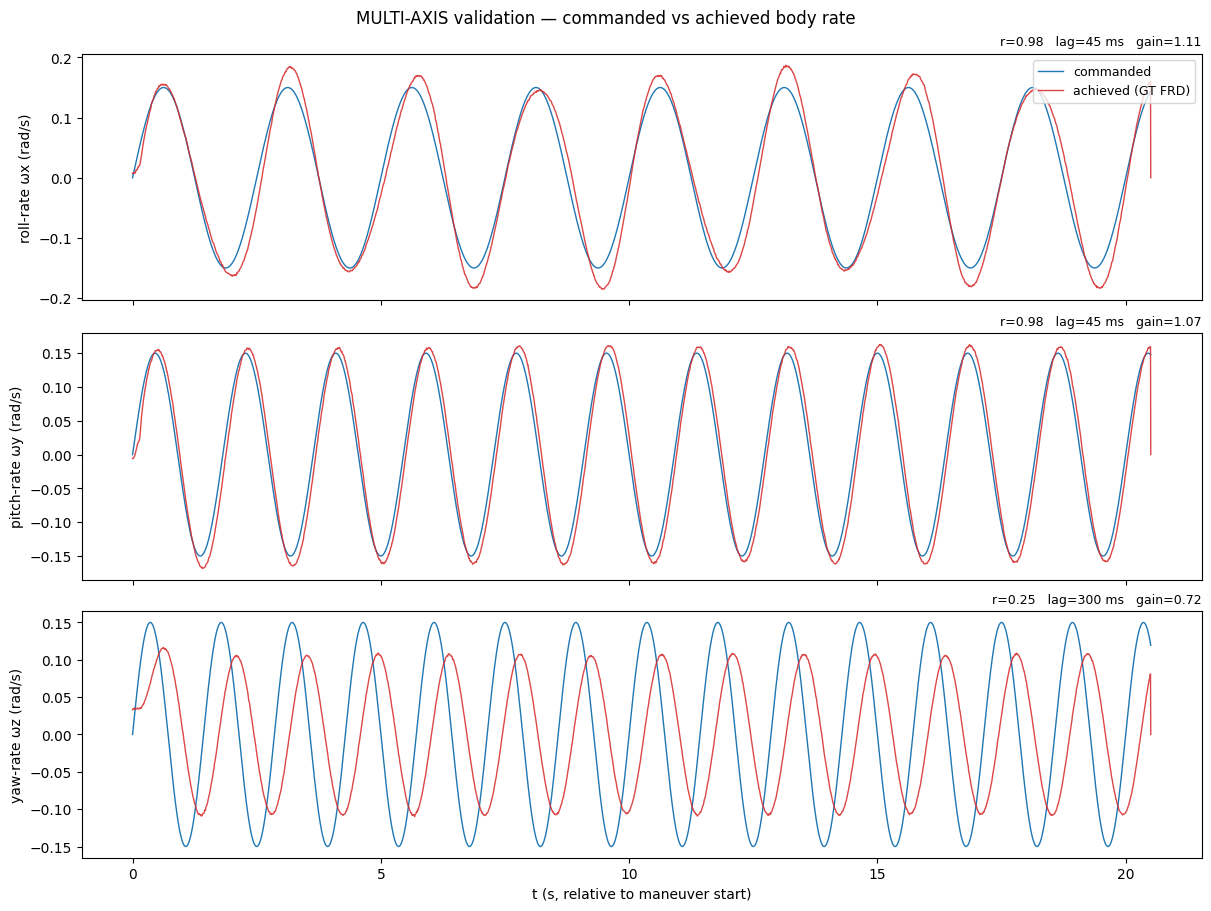

In [2]:
def validate_input(run, title):
    res = aic.per_run_metrics(run, return_series=True)
    if res is None:
        print(f'{title}: too few in-window samples — skip.'); return
    metrics, s = res
    t, cmd, tel = s['t'], s['cmd'], s['tel']
    print(f'=== {title} ===   {os.path.basename(run.rstrip("/"))}')
    print(f'  {"axis":14s} {"r":>6s} {"lag_ms":>8s} {"gain":>7s}')
    for ax in aic.AXES:
        m = metrics[ax]; print(f'  {AXLBL[ax]:14s} {m["r"]:6.2f} {m["lag_ms"]:8.1f} {m["gain"]:7.3f}')
    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, constrained_layout=True)
    for k, ax in enumerate(aic.AXES):
        a = axes[k]
        a.plot(t, cmd[:, k], color='C0', lw=1.0, label='commanded')
        a.plot(t, tel[:, k], color='C3', lw=1.0, alpha=0.85, label='achieved (GT FRD)')
        a.set_ylabel(f'{AXLBL[ax]} (rad/s)')
        m = metrics[ax]
        a.set_title(f'r={m["r"]:.2f}   lag={m["lag_ms"]:.0f} ms   gain={m["gain"]:.2f}',
                    fontsize=9, loc='right')
        if k == 0: a.legend(loc='upper right', fontsize=9)
    axes[-1].set_xlabel('t (s, relative to maneuver start)')
    fig.suptitle(f'{title} — commanded vs achieved body rate', fontsize=12)
    plt.show()

if MULTI_RUN:
    validate_input(MULTI_RUN, 'MULTI-AXIS validation')
else:
    print('No multi-axis validation run found.')

## 2 — Landing: THRUST-MAP validation (thrust staircase)

The landing profile commands a thrust_norm **staircase** (0.74 → drop 0.01/step, rates 0)
from 20 m, stopping at 1 m on GT altitude. Achieved net-down accel `a_z = a_down + g`
vs commanded `thrust_norm` should be **linear**, crossing `a_z=0` at the hover thrust_norm
(~0.738); the fit's zero-crossing + slope validate the thrust map `0.738 − B_T/42.3`.
(Rate gain+lag is the multisine's job — rates are ~0 here.)

thrust-map fit (per-step settled means):  a_z = -20.8*thr + +15.37
  hover thrust_norm (a_z=0) = 0.741   (expect ~0.738)
  slope = -20.8 m/s^2 per thrust_norm  (-> mass ~ 2.04 kg)
  per-step settled std = 0.004 m/s^2  | thrust range 0.68-0.74


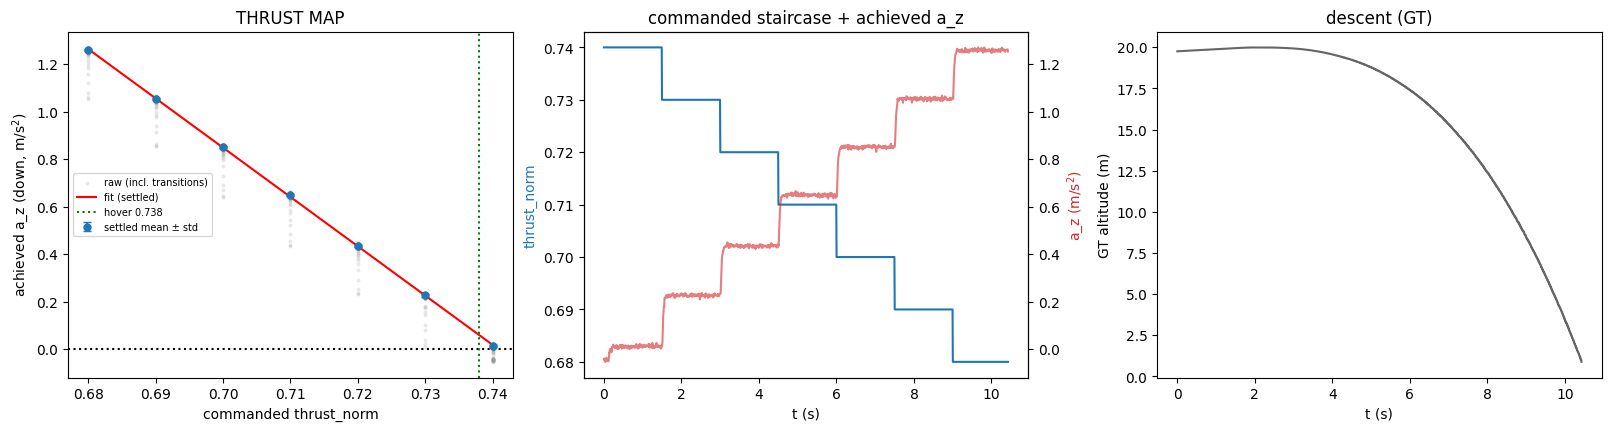

In [3]:
if not LANDING_RUN:
    print('No landing run found.')
else:
    _gt  = np.load(LANDING_RUN + '/Ground_Truth.npy',   allow_pickle=True).item()
    _tel = np.load(LANDING_RUN + '/Telemetry_Data.npy', allow_pickle=True).item()
    _cmd = np.asarray(_gt.get('Command', []), float)
    _thr = _cmd[:, 3] if (_cmd.ndim == 2 and _cmd.shape[1] >= 4) else np.array([])
    if _thr.size == 0 or _thr.min() <= 0.4 or _thr.max() >= 0.99:
        print('Not a thrust-staircase recording (Command[:,3] is not a thrust_norm).')
        print('Re-record: CALIB_APP=apps/record_input_validation.py VALIDATION_PROFILE=landing '
              'bash scripts/run_input_calibration.sh')
    else:
        g = 9.81
        _t  = np.asarray(_gt['Time'], float)
        n   = min(len(_t), len(_thr)); _t, _thr = _t[:n], _thr[:n]
        _ad = np.array([a.down_m_s2 for a in _tel['Acceleration']])
        _ats = np.asarray(_tel['Odometry Timestamp'], float) - _gt['Start Time']
        _m = min(len(_ad), len(_ats)); _ad, _ats = _ad[:_m], _ats[:_m]
        a_z = np.interp(_t, _ats, _ad) + g                       # net down accel (0 at hover)
        U, T = _gt['UAV Pose'], _gt['Target Pose']
        alt = np.array([abs(u.position.z - t.position.z) for u, t in zip(U, T)])[:n]
        msk = np.isfinite(a_z) & np.isfinite(_thr)
        # Per-thrust-level SETTLED means (last 40% of each step) = the clean thrust-map
        # points; the raw scatter (light) shows the brief inter-step transition tails.
        lv, az_m, az_s = [], [], []
        for L in sorted(set(np.round(_thr, 2))):
            sm = (np.round(_thr, 2) == L) & msk
            if sm.sum() < 5: continue
            tt = _t[sm]; seg = a_z[sm][tt >= tt.min() + 0.6 * (tt.max() - tt.min())]
            if seg.size:
                lv.append(L); az_m.append(float(np.nanmean(seg))); az_s.append(float(np.nanstd(seg)))
        lv, az_m, az_s = np.array(lv), np.array(az_m), np.array(az_s)
        sl, b = np.polyfit(lv, az_m, 1); hover = -b / sl if sl else float('nan')
        print(f'thrust-map fit (per-step settled means):  a_z = {sl:.1f}*thr + {b:+.2f}')
        print(f'  hover thrust_norm (a_z=0) = {hover:.3f}   (expect ~0.738)')
        print(f'  slope = {sl:.1f} m/s^2 per thrust_norm  (-> mass ~ {-42.3/sl:.2f} kg)')
        print(f'  per-step settled std = {np.nanmean(az_s):.3f} m/s^2  | thrust range {lv.min():.2f}-{lv.max():.2f}')
        fig, ax = plt.subplots(1, 3, figsize=(16, 4.2), constrained_layout=True)
        ax[0].scatter(_thr[msk], a_z[msk], s=4, alpha=0.15, color='0.6', label='raw (incl. transitions)')
        ax[0].errorbar(lv, az_m, yerr=az_s, fmt='o', color='C0', ms=5, capsize=3, label='settled mean ± std')
        xx = np.linspace(lv.min(), lv.max(), 50)
        ax[0].plot(xx, sl*xx + b, 'r-', lw=1.5, label='fit (settled)')
        ax[0].axhline(0, color='k', ls=':'); ax[0].axvline(0.738, color='g', ls=':', label='hover 0.738')
        ax[0].set_xlabel('commanded thrust_norm'); ax[0].set_ylabel('achieved a_z (down, m/s$^2$)')
        ax[0].set_title('THRUST MAP'); ax[0].legend(fontsize=7)
        ax[1].plot(_t, _thr, 'C0'); ax[1].set_ylabel('thrust_norm', color='C0'); ax[1].set_xlabel('t (s)')
        ax[1].set_title('commanded staircase + achieved a_z')
        axt = ax[1].twinx(); axt.plot(_t, a_z, 'C3', alpha=0.6); axt.set_ylabel('a_z (m/s$^2$)', color='C3')
        ax[2].plot(_t, alt, '0.4'); ax[2].set_ylabel('GT altitude (m)'); ax[2].set_xlabel('t (s)')
        ax[2].set_title('descent (GT)')
        plt.show()